In [ ]:
import os
import sys
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import onnx
import onnxruntime as ort
import json

from hipe4ml.model_handler import ModelHandler
from hipe4ml.tree_handler import TreeHandler
from hipe4ml import plot_utils, analysis_utils
from hipe4ml_converter.h4ml_converter import H4MLConverter
# from hipe4ml.analysis_utils import train_test_generator, bdt_efficiency_array

# from parquet_to_root import parquet_to_root # Apparently parquet_to_root is missing from the repo
from sklearn.metrics import roc_curve

from importlib import reload

## Configuration

In [8]:
# Parameters for training
N_ESTIMATORS = (20, 1000)
MAX_DEPTH = (2, 6)
LEARNING_RATE = (0.01, 0.1)
N_JOBS = 10
TIMEOUT = 60
N_TRIALS = 3

## Default:
# N_ESTIMATORS = (20, 1000)
# MAX_DEPTH = (2, 6)
# LEARNING_RATE = (0.01, 0.1)
# N_JOBS = 10
# TIMEOUT = 60
# N_TRIALS = 100

# pT and centrality bins and type for cut and JSON
PT_BINS = [(0, 100)]  # pT bins
# CENT_BINS = [(0, 100)]  # centrality bins #(-1, 100) for pp? Not used?
CENT_Type = "kCentFT0C" # kCentFT0C, kCentFT0A, kCentFT0M

# Input tree files (from dielectronall table (and ReducedEventsExtended for Cent))
DATA_FILE = "~/alice/datasets/data/Maker+Reader/LHC24an_pass1_skimmed_Train742850_Small/jobs/0574/hy_5746268/AOD/001/AO2D.root"
PROMPTMC_FILE = "~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b16_Train740630_Small/jobs/0571/hy_5719799/0001/AO2D.root"
NONPROMPTMC_FILE = "~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b17_Train742849_Small/jobs/0574/hy_5746177/0001/AO2D.root"

# Output directory
OUT_DIR = "output/MultiClass"
FIG_DIR = "output/MultiClass/fig"

In [9]:
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True) 

## Utils

In [10]:
def infer_n_features(mh: ModelHandler, input_table=None):
    try:
        return mh.model.n_features_in_
    except AttributeError:
        if input_table is not None:
            return pd.read_parquet(input_table).shape[1]
        raise ValueError("Cannot determine n_features. Provide input table.")

def significance_array(y_score, bkg_mass, signal_efficiencies, lumi, xsec, acc_eff, delta_y, br, sig_win_width, sb_left, sb_right, n_points=100):
    thresholds = np.linspace(np.min(y_score), np.max(y_score), n_points)
    sig_array = []

    for i, thr in enumerate(thresholds[:-1]):
        selected = y_score > thr
        selected_bkg_mass = bkg_mass[selected]

        sideband_mask = ((selected_bkg_mass > sb_left[0]) & (selected_bkg_mass < sb_left[1])) | \
                        ((selected_bkg_mass > sb_right[0]) & (selected_bkg_mass < sb_right[1]))
        bkg_sb = selected_bkg_mass[sideband_mask]
        sb_width = (sb_left[1] - sb_left[0]) + (sb_right[1] - sb_right[0])

        bkg_est_in_window = (len(bkg_sb) / sb_width) * sig_win_width if sb_width > 0 else 0

        signal_eff = signal_efficiencies[i]
        signal_yield = xsec * acc_eff * signal_eff * lumi * delta_y * br

        S = signal_yield
        B = bkg_est_in_window
        if S + B > 0:
            sig = S / np.sqrt(S + B)
        else:
            sig = 0
        
        sig_array.append(sig)

    return np.array(sig_array), thresholds

def export_to_onnx(model_handler, prefix, feature_names, input_table=None):
    n_features = infer_n_features(model_handler, input_table)
    print(f"Inferred number of input features: {n_features}")

    converter = H4MLConverter(model_handler)
    onnx_model = converter.convert_model_onnx(1)

    for i, name in enumerate(feature_names):
        meta = onnx_model.metadata_props.add()
        meta.key = f"feature_{i}"
        meta.value = name

    out_path = f"{prefix}.onnx"
    converter.dump_model_onnx(out_path)
    print(f"Exported ONNX: {out_path}")

    model = onnx.load(out_path)
    for input_tensor in model.graph.input:
        dims = [d.dim_value if d.HasField("dim_value") else "None" for d in input_tensor.type.tensor_type.shape.dim]
        print(f"  - {input_tensor.name}: shape={dims}")


In [11]:
best_cuts_dict = {}
pre_cut = '1.8 < fMass < 5.0 and -0.4 < fDcaXY1 < 0.4 and -0.4 < fDcaZ1 < 0.4 and -0.4 < fDcaXY2 < 0.4 and -0.4 < fDcaZ2 < 0.4'

## Read Input (can take a while)

In [12]:
promptH_origin = TreeHandler(PROMPTMC_FILE,'O2rtdielectronall', folder_name="DF*")

Reading ~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b16_Train740630_Small/jobs/0571/hy_5719799/0001/AO2D.root:DF_2400032162536928/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b16_Train740630_Small/jobs/0571/hy_5719799/0001/AO2D.root:DF_2400032162536896/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b16_Train740630_Small/jobs/0571/hy_5719799/0001/AO2D.root:DF_2400032162536864/O2rtdielectronall;1


...

/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b16_Train740630_Small/jobs/0571/hy_5719799/0001/AO2D.root:DF_2400032108456192/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b16_Train740630_Small/jobs/0571/hy_5719799/0001/AO2D.root:DF_2400032108456160/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


In [13]:
nonpromptH_origin = TreeHandler(NONPROMPTMC_FILE, 'O2rtdielectronall', folder_name="DF*")

Reading ~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b17_Train742849_Small/jobs/0574/hy_5746177/0001/AO2D.root:DF_2400032113298528/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b17_Train742849_Small/jobs/0574/hy_5746177/0001/AO2D.root:DF_2400032113298496/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b17_Train742849_Small/jobs/0574/hy_5746177/0001/AO2D.root:DF_2400032113298464/O2rtdielectronall;1


...

/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b17_Train742849_Small/jobs/0574/hy_5746177/0001/AO2D.root:DF_2400032061843072/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/MC/derivedMC/Maker+DQEff/Ago26/LHC25b17_Train742849_Small/jobs/0574/hy_5746177/0001/AO2D.root:DF_2400032061843040/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


In [14]:
dataH_origin = TreeHandler(DATA_FILE,'O2rtdielectronall', folder_name="DF*")

Reading ~/alice/datasets/data/Maker+Reader/LHC24an_pass1_skimmed_Train742850_Small/jobs/0574/hy_5746268/AOD/001/AO2D.root:DF_2396275149557984/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/data/Maker+Reader/LHC24an_pass1_skimmed_Train742850_Small/jobs/0574/hy_5746268/AOD/001/AO2D.root:DF_2396275149539840/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/data/Maker+Reader/LHC24an_pass1_skimmed_Train742850_Small/jobs/0574/hy_5746268/AOD/001/AO2D.root:DF_2396275149529408/O2rtdielectronall;1


...

/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/data/Maker+Reader/LHC24an_pass1_skimmed_Train742850_Small/jobs/0574/hy_5746268/AOD/001/AO2D.root:DF_2396275022710880/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


Reading ~/alice/datasets/data/Maker+Reader/LHC24an_pass1_skimmed_Train742850_Small/jobs/0574/hy_5746268/AOD/001/AO2D.root:DF_2396275022695776/O2rtdielectronall;1


/home/ferrandi/alice/sw/ubuntu2004_x86-64/Python-modules/1.0-local3/lib/python3.10/site-packages/uproot/interpretation/library.py:743: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  return (getattr(pandas, "RangeIndex", pandas.Int64Index), pandas.Int64Index)


In [15]:
# Pre cuts
# for centmin, centmax in CENT_BINS:
# for i, (ptmin, ptmax) in enumerate(PT_BINS):
ptmin, ptmax = PT_BINS[0]  # Assuming only one pT bin for now

print(f"Processing pT bin {ptmin} - {ptmax} GeV/c")
tag = f'pt{ptmin}_{ptmax}'
#cut_cent = f'{CENT_Type} >= {centmin} and {CENT_Type} < {centmax}'
cut_pt = f'fPt >= {ptmin} and fPt < {ptmax}'
#cut = f'{pre_cut} and {cut_cent} and {cut_pt}'
cut = f'{pre_cut} and {cut_pt}'


Processing pT bin 0 - 100 GeV/c


## Distributions Plots

In [16]:
# Prepare datasets
promptH = promptH_origin.get_subset(frac=1.0)
promptH.apply_preselections(cut)
promptH.apply_preselections('fMcDecision == 1 and 2.4 < fMass < 3.2')
nonpromptH = nonpromptH_origin.get_subset(frac=1.0)
nonpromptH.apply_preselections(cut)
nonpromptH.apply_preselections('fMcDecision == 2 and 2.4 < fMass < 3.2')
dataH = dataH_origin.get_subset(frac=1.0)
dataH = dataH.get_subset(cut)
bkgH = dataH.get_subset('1.8 < fMass < 2.4 or 3.2 < fMass < 5.0', frac=1.0) # size=promptH.get_n_cand() * 2) # Neet to optimize size ratio

branches_to_remove = ["fSign", "fFilterMap", "fMcDecision", 
    "fDCAxyzTrk0KF", "fDCAxyzTrk1KF", "fDCAxyzBetweenTrksKF",
    "fDCAxyTrk0KF", "fDCAxyTrk1KF", "fDCAxyBetweenTrksKF",
    "fDeviationTrk0KF", "fDeviationTrk1KF", "fDeviationxyTrk0KF", "fDeviationxyTrk1KF",
    "fMassKFGeo", "fChi2OverNDFKFGeo", "fDecayLengthKFGeo", "fDecayLengthOverErrKFGeo",
    "fDecayLengthXYKFGeo", "fDecayLengthXYOverErrKFGeo", "fPseudoproperDecayTimeKFGeo", "fPseudoproperDecayTimeErrKFGeo",
    "fCosPAKFGeo", "fPairDCAxyz", "fPairDCAxy",
    "fDeviationPairKF", "fDeviationxyPairKF",
    "fMassKFGeoTop", "fChi2OverNDFKFGeoTop"]

vars_to_draw = promptH.get_var_names()
for b in branches_to_remove:
    if b in vars_to_draw:
        vars_to_draw.remove(b)

Nvars = len(vars_to_draw)
NPlots = 6
NVarPerPlot = Nvars // NPlots + (Nvars % NPlots > 0)

leg_labels = ['background', 'prompt', 'nonprompt']

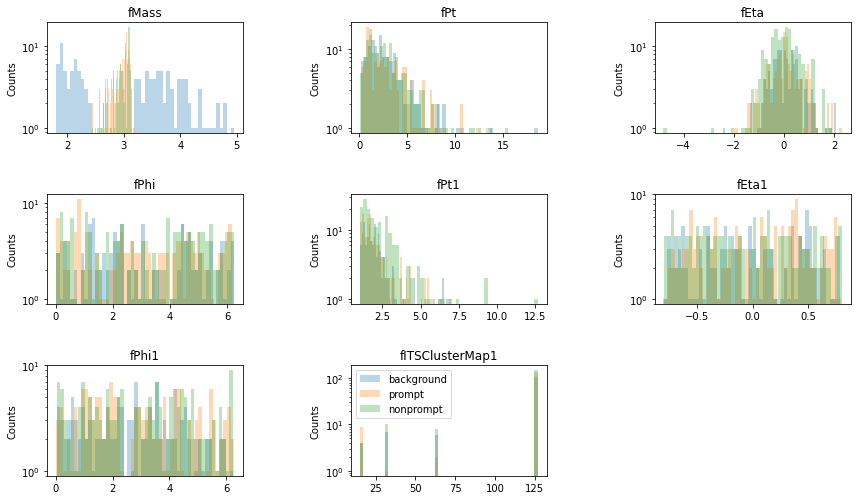

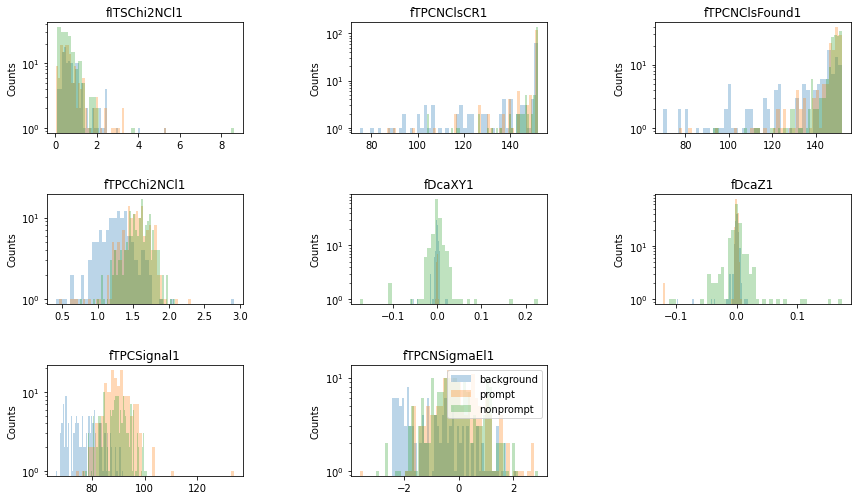

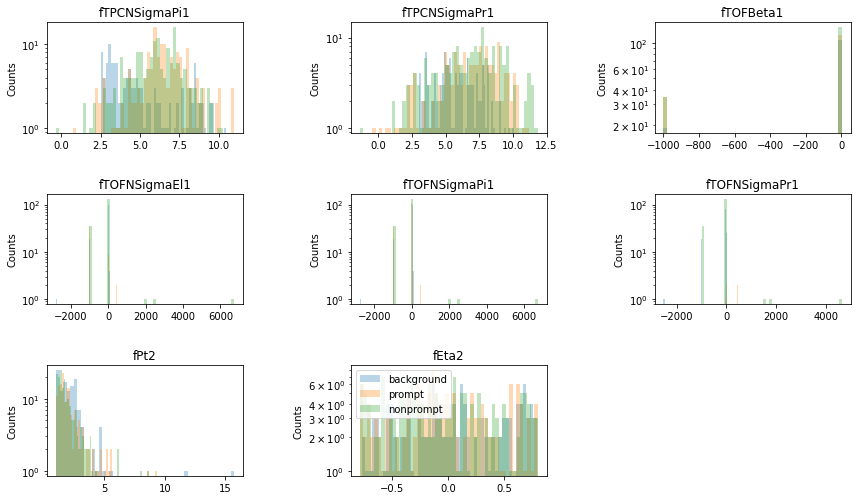

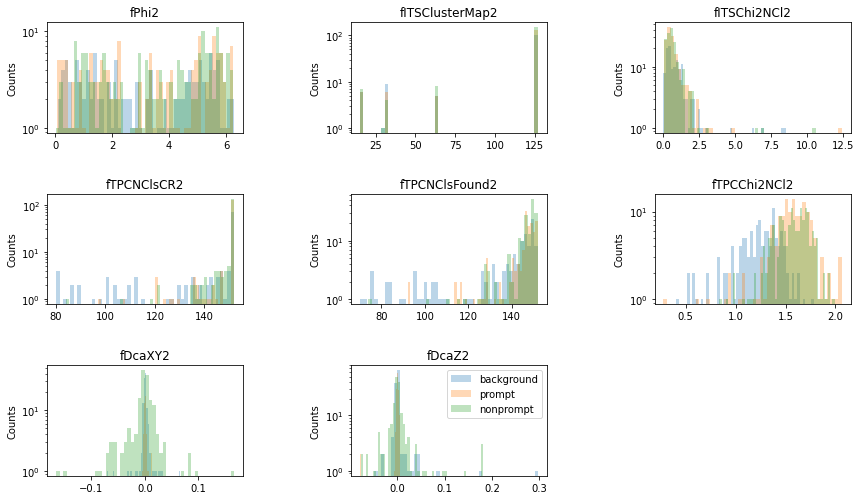

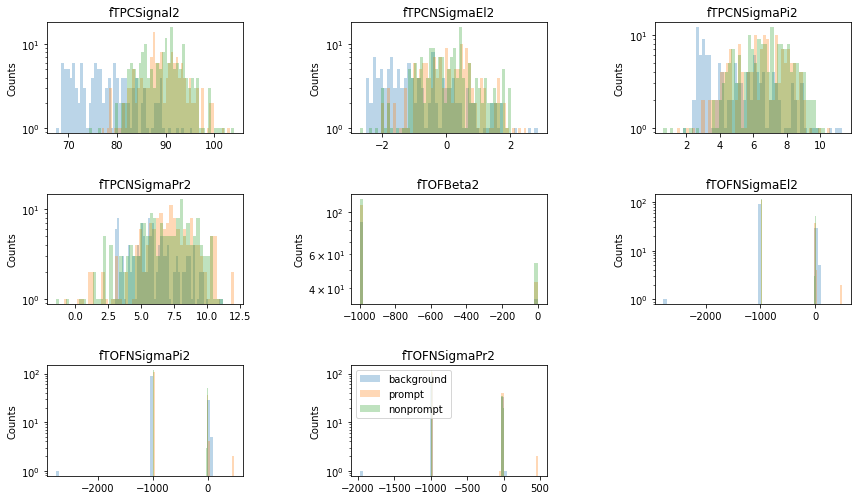

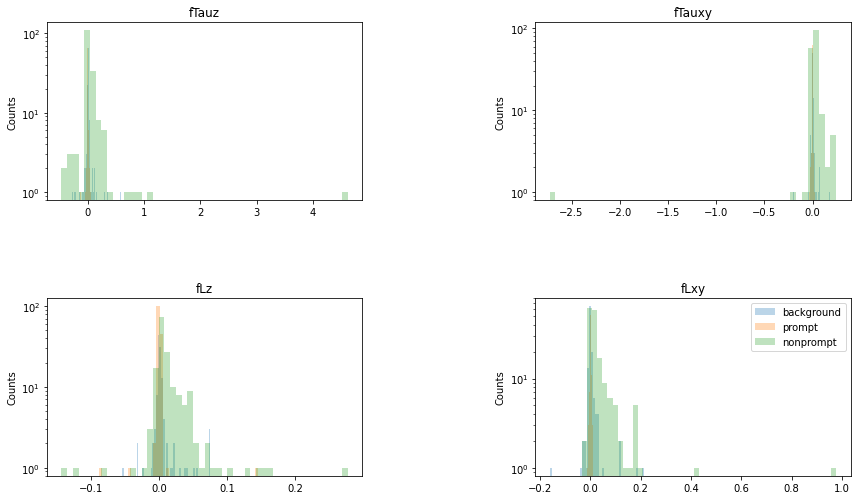

In [17]:
for i in range(NPlots):
    start_idx = i * NVarPerPlot
    end_idx = min(start_idx + NVarPerPlot, Nvars)
    vars_subset = vars_to_draw[start_idx:end_idx]
    
    plot_utils.plot_distr([bkgH, promptH, nonpromptH], vars_subset, bins=50, labels=leg_labels, log=True, density=False, figsize=(12, 7), alpha=0.3, grid=False)
    plt.subplots_adjust(left=0.06, bottom=0.06, right=0.99, top=0.96, hspace=0.55, wspace=0.55)
    plt.savefig(f'{FIG_DIR}/plot_distr_origin_{tag}_part{i+1}.png')
    plt.show()
    plt.close()

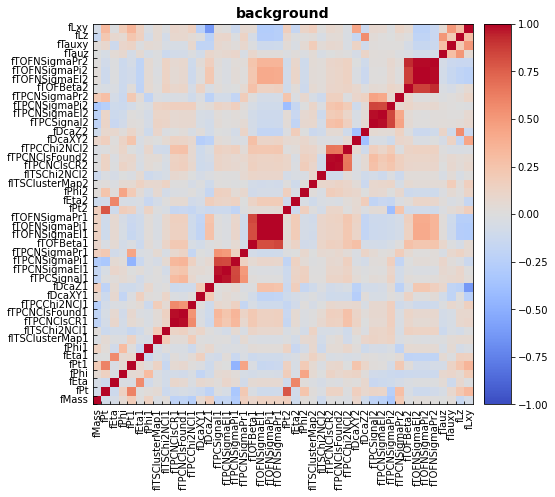

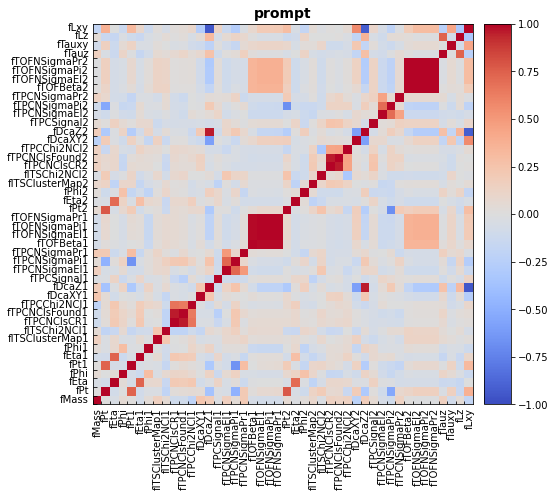

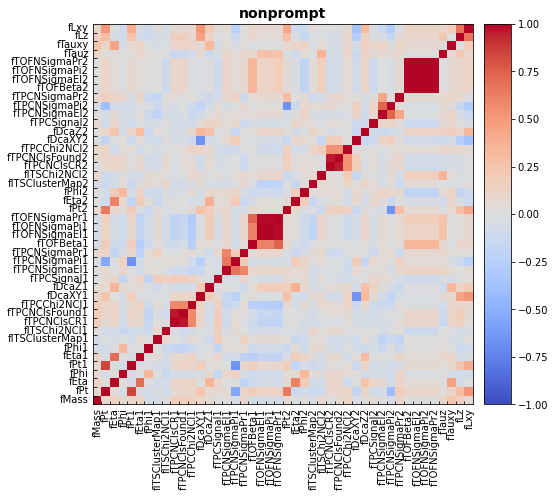

In [18]:
corr_plots = plot_utils.plot_corr([bkgH, promptH, nonpromptH], vars_to_draw, leg_labels)
corr_plots[0].savefig(f'{FIG_DIR}/corr_bkg_origin_{tag}.png', bbox_inches='tight')
corr_plots[1].savefig(f'{FIG_DIR}/corr_prompt_origin_{tag}.png', bbox_inches='tight')
corr_plots[2].savefig(f'{FIG_DIR}/corr_nonprompt_origin_{tag}.png', bbox_inches='tight')

In [19]:
# Remove variables not used for training and plot distributions and correlations
branches_to_remove_for_training = ["fEta", "fPhi",
    "fPt1", "fEta1", "fPhi1", "fTPCNClsFound1",
    "fDcaXY1", "fDcaZ1",
    "fTPCNSigmaPr1", "fTPCSignal1", "fTPCNSigmaPi1",
    "fTOFBeta1", "fTOFNSigmaPi1", "fTOFNSigmaPr1", "fTOFNSigmaEl1",
    "fPt2", "fEta2", "fPhi2", "fTPCNClsFound2",
    "fDcaXY2", "fDcaZ2",
    "fTPCNSigmaPr2", "fTPCSignal2", "fTPCNSigmaPi2",
    "fTOFBeta2", "fTOFNSigmaPi2", "fTOFNSigmaPr2", "fTOFNSigmaEl2",
    "fLz", "fLxy", "fTauz", "fTauxy"]        

for b in branches_to_remove_for_training:
    if b in vars_to_draw:
        vars_to_draw.remove(b)


# plot_utils.plot_distr([bkgH, promptH, nonpromptH], vars_to_draw, bins=100, labels=leg_labels, log=True, density=True, figsize=(12, 7), alpha=0.3, grid=False)
# plt.savefig(f'{FIG_DIR}/plot_distr_pt{ptmin}_{ptmax}.png')

# plt.subplots_adjust(left=0.06, bottom=0.06, right=0.99, top=0.96, hspace=0.55, wspace=0.55)
# corr_plots = plot_utils.plot_corr([bkgH, promptH, nonpromptH], vars_to_draw, leg_labels)
# corr_plots[0].savefig(f'{FIG_DIR}/plot_corr_bkg_{tag}.png', bbox_inches='tight')
# corr_plots[1].savefig(f'{FIG_DIR}/plot_corr_sig_{tag}.png', bbox_inches='tight')

In [20]:
# Remove mass and pT from features
features_for_train = vars_to_draw.copy()
extraFeaturesToRemove = ["fPt", "fMass"]
for b in extraFeaturesToRemove:
    if b in features_for_train:
        features_for_train.remove(b)

# Train model
model_clf = xgb.XGBClassifier()
model_hdl = ModelHandler(model_clf, features_for_train)

## Model Training

In [ ]:
train_test_data = analysis_utils.train_test_generator([bkgH, promptH, nonpromptH], [0, 1, 2], test_size=0.2, random_state=42)
hyper_pars_ranges = {'n_estimators': N_ESTIMATORS, 'max_depth': MAX_DEPTH, 'learning_rate': LEARNING_RATE}
model_hdl.optimize_params_optuna(train_test_data, hyper_pars_ranges, cross_val_scoring='roc_auc_ovo', timeout=TIMEOUT, n_jobs=N_JOBS, n_trials=N_TRIALS, direction='maximize')


[I 2026-09-10 16:15:03,061] A new study created in memory with name: no-name-b94160f5-40e2-4683-a706-ea32f3106a4a
[I 2026-09-10 16:15:44,821] Trial 2 finished with value: 0.735723383567888 and parameters: {'n_estimators': 761, 'max_depth': 3, 'learning_rate': 0.06456651976288863}. Best is trial 2 with value: 0.735723383567888.
[I 2026-09-10 16:15:49,609] Trial 1 finished with value: 0.744151907943331 and parameters: {'n_estimators': 517, 'max_depth': 6, 'learning_rate': 0.05655599805858158}. Best is trial 1 with value: 0.744151907943331.
[I 2026-09-10 16:15:50,212] Trial 0 finished with value: 0.7253641033330641 and parameters: {'n_estimators': 966, 'max_depth': 3, 'learning_rate': 0.09198377204319708}. Best is trial 1 with value: 0.744151907943331.


Number of finished trials: 3
Best trial:
Value: 0.744151907943331
Params: 
    n_estimators: 517
    max_depth: 6
    learning_rate: 0.05655599805858158


In [22]:
model_hdl.train_test_model(train_test_data, multi_class_opt="ovo")

Training xgboost model for classification
Number of detected classes: 3
Training the model: ...
Training the model: Done!
Testing the model: ...
ROC_AUC_score: 0.735007
Testing the model: Done!


## Testing

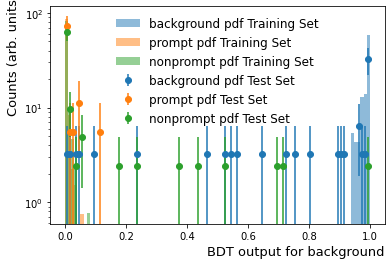

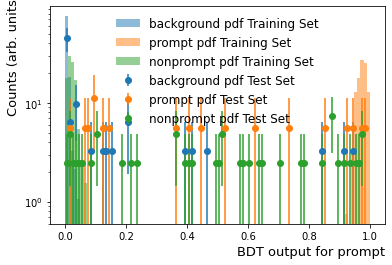

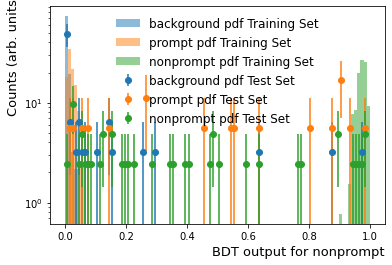

In [23]:
# Plot model predictions for both training and test samples

ml_out_fig = plot_utils.plot_output_train_test(model_hdl, train_test_data, bins=100, 
                                            output_margin=False, labels=leg_labels,
                                            logscale=True, density=True)

plt.show()

figLabels = ['bkg', 'prompt', 'nonprompt']
for i, fig in enumerate(ml_out_fig):
    fig.savefig(f'{FIG_DIR}/prediction_{figLabels[i]}_{tag}.pdf', bbox_inches='tight')



## BDT Efficiency

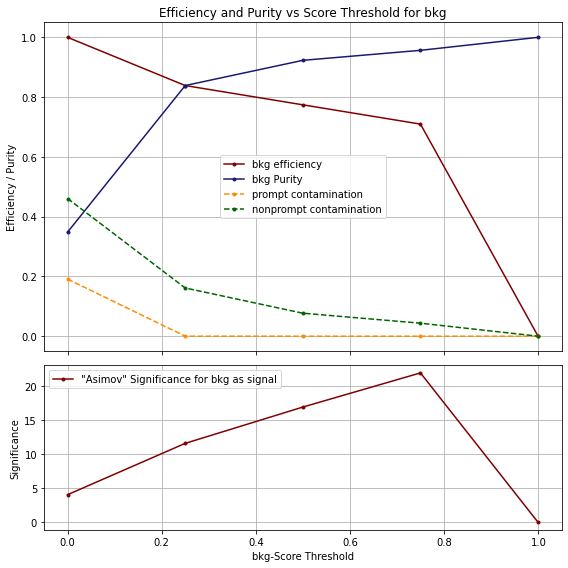

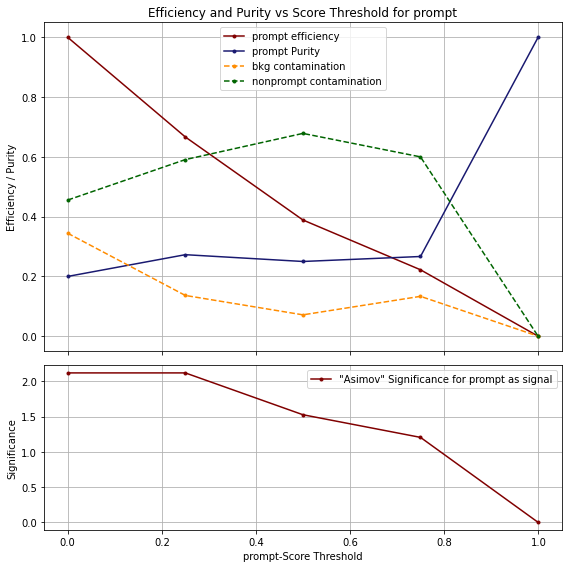

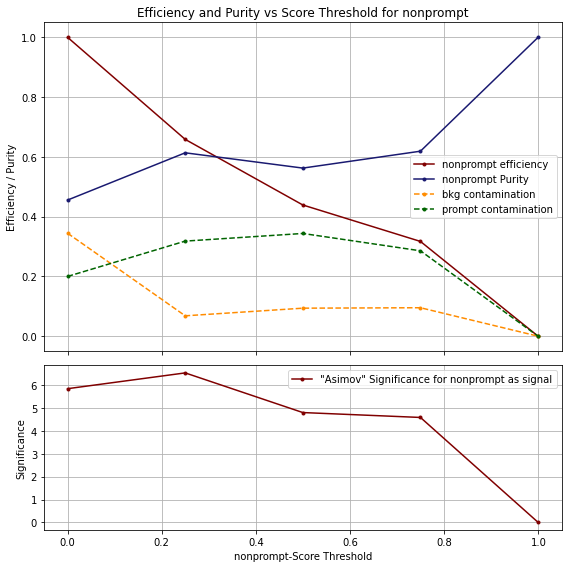

In [ ]:
reload(analysis_utils)
reload(plot_utils)
y_pred_test = model_hdl.predict(train_test_data[2], output_margin=False)
colors = ['darkorange', 'darkgreen']

bdtEff_testSample, thresholds_test, bdtCont_testSample, bdtSignif_testSample = analysis_utils.bdt_efficiency_array(train_test_data[3], y_pred_test, n_points=5, calculate_contamination=True)

bdt_eff_figs = plot_utils.plot_bdt_eff(thresholds_test, bdtEff_testSample, bdtCont_testSample, bdtSignif_testSample, figLabels, contaminColors=colors)

for i, fig in enumerate(bdt_eff_figs):
    fig.savefig(f'{FIG_DIR}/BDT_Efficiencies_{figLabels[i]}_{tag}.pdf', bbox_inches='tight')


1.0


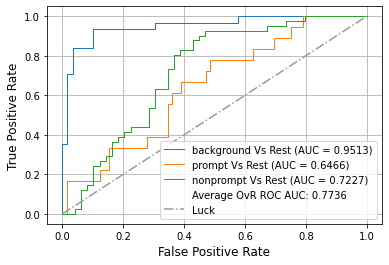

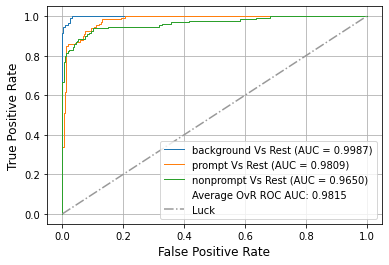

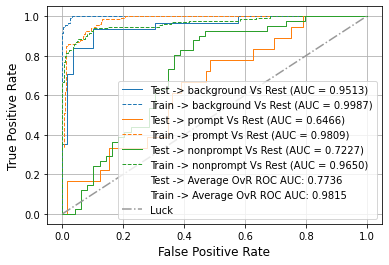

In [156]:
y_pred_train = model_hdl.predict(train_test_data[0], output_margin=False)
y_pred_test = model_hdl.predict(train_test_data[2], output_margin=False)
print(np.sum(y_pred_train[0]))
roc_train_test_fig = plot_utils.plot_roc_train_test(train_test_data[3], y_pred_test,
                                                    train_test_data[1], y_pred_train, None, leg_labels, 'macro', multi_class_opt="ovr")
# plt.savefig(f'{outDir}/roc.pdf')
roc_train_test_fig.savefig(f'{FIG_DIR}/roc_train_test_{tag}.pdf')

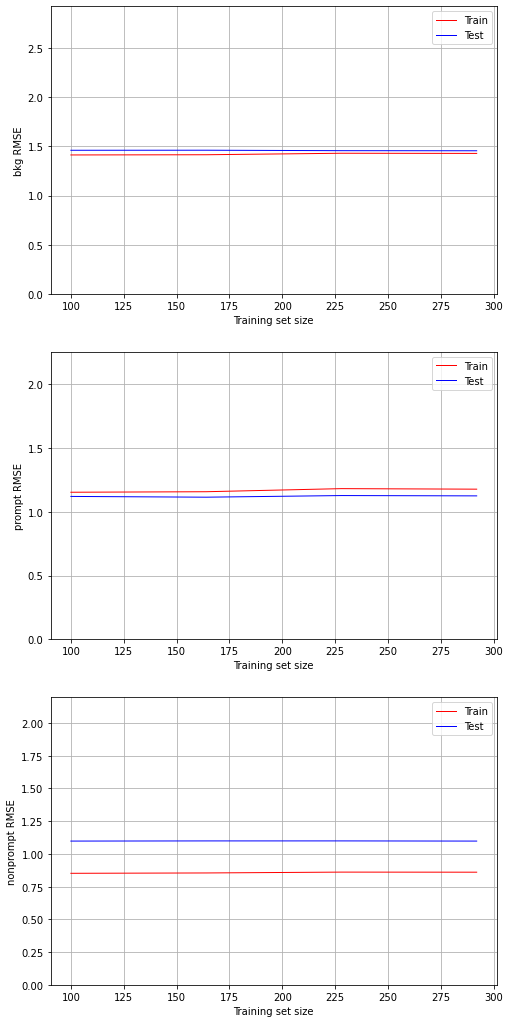

In [ ]:
reload(plot_utils)
learn_curve_fig = plot_utils.plot_learning_curves(model_hdl, train_test_data, 4, figLabels)
learn_curve_fig.savefig(f'{FIG_DIR}/learning_curves_{tag}.pdf')

In [ ]:
train_test_data_binary = analysis_utils.train_test_generator([bkgH, promptH], [0, 1], test_size=0.2, random_state=42)

train_test_data_binary[0].shape: (220, 72)
train_test_data_binary[1].shape: (220,)
train_test_data_binary[2].shape: (55, 72)
train_test_data_binary[3].shape: (55,)
(220,)


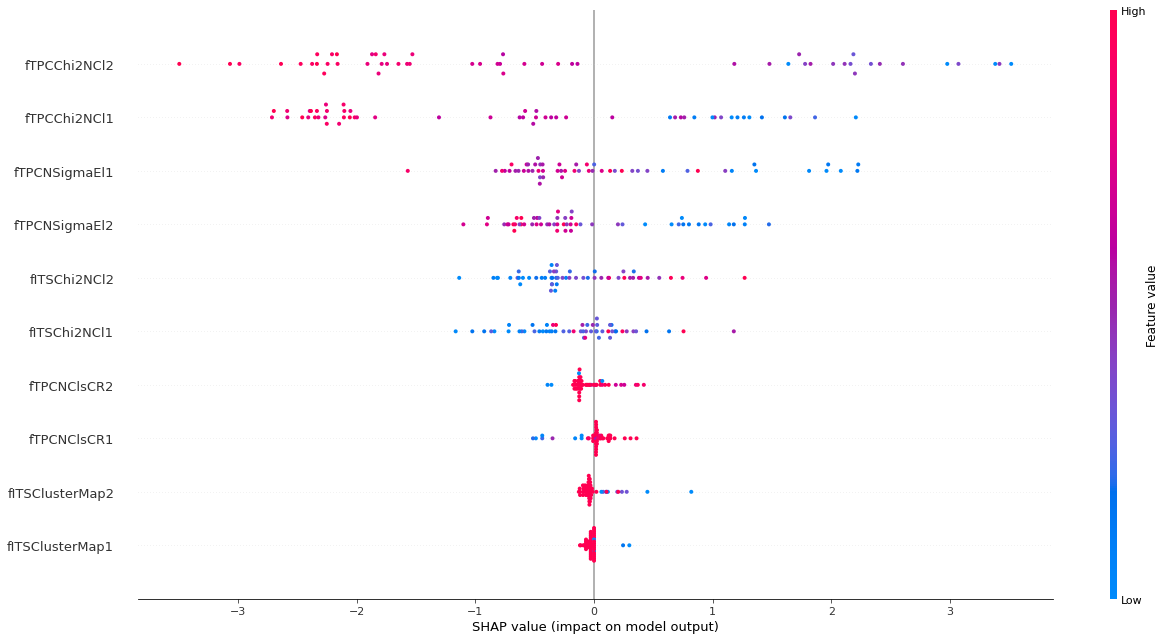

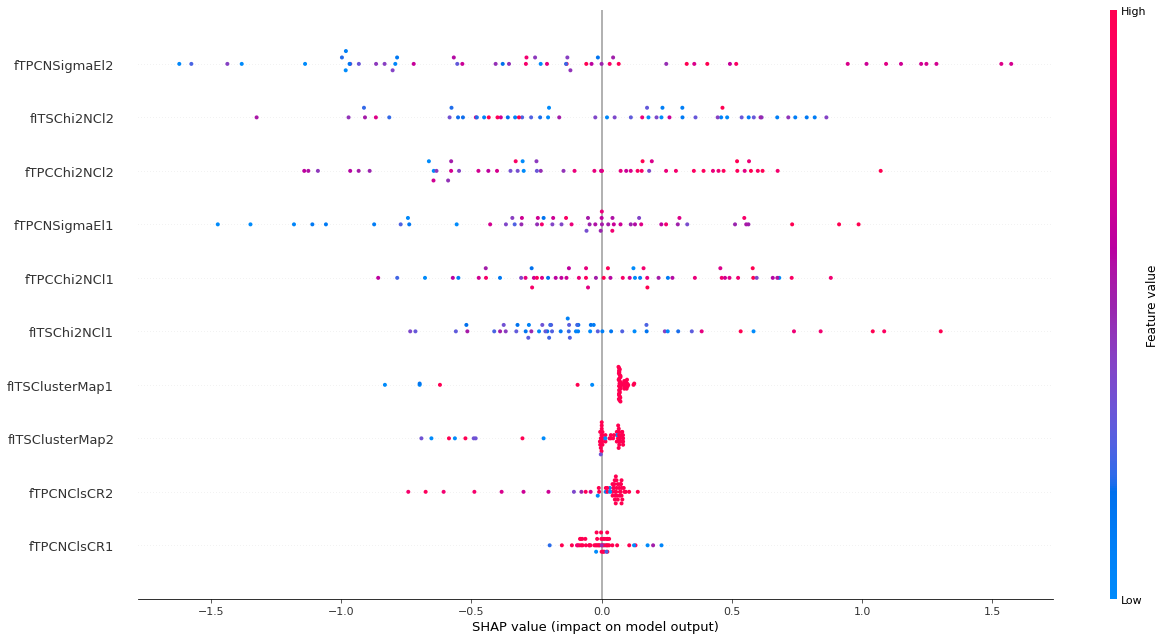

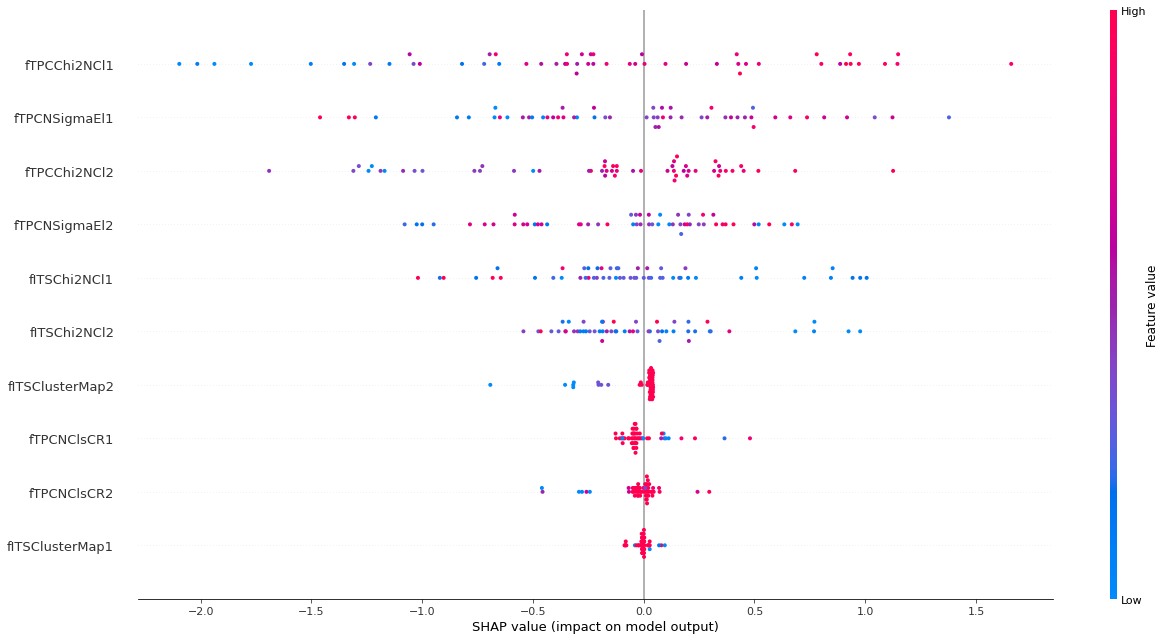

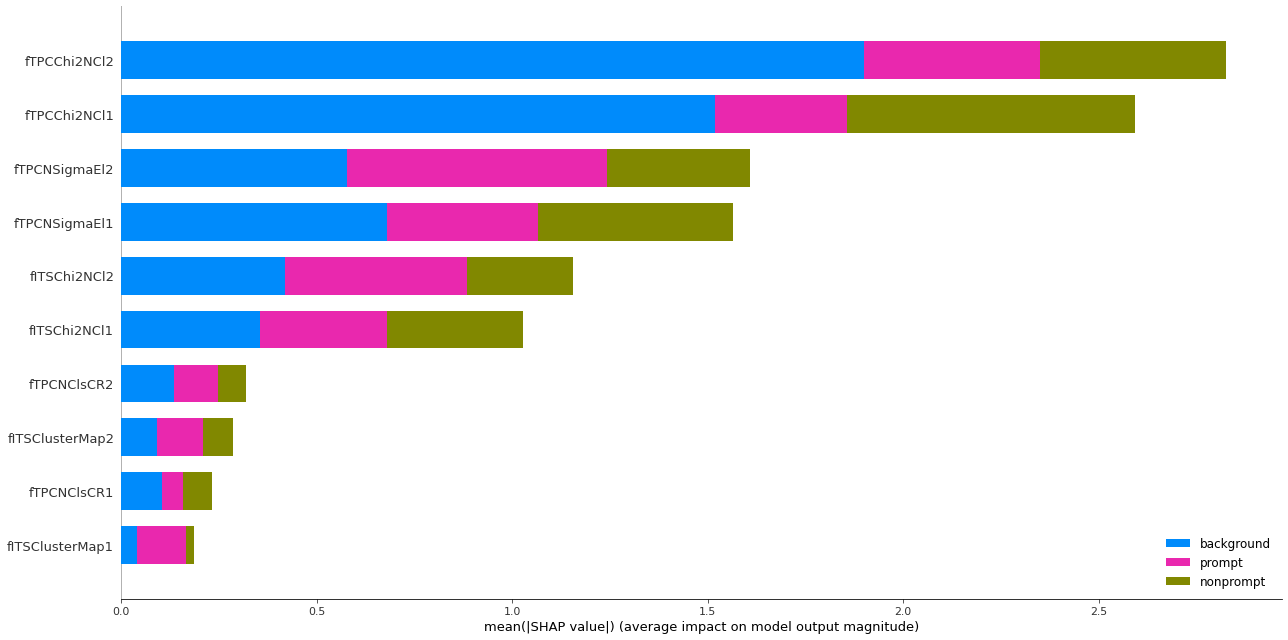

In [25]:
shap_figs = plot_utils.plot_feature_imp(train_test_data[2], train_test_data[3], model_hdl, labels=leg_labels) 

# only show the SHAP summary plot
# plt.close(shap_figs[0])
# plt.close(shap_figs[1])
# plt.close(shap_figs[2])
plt.show()  

## Exporting

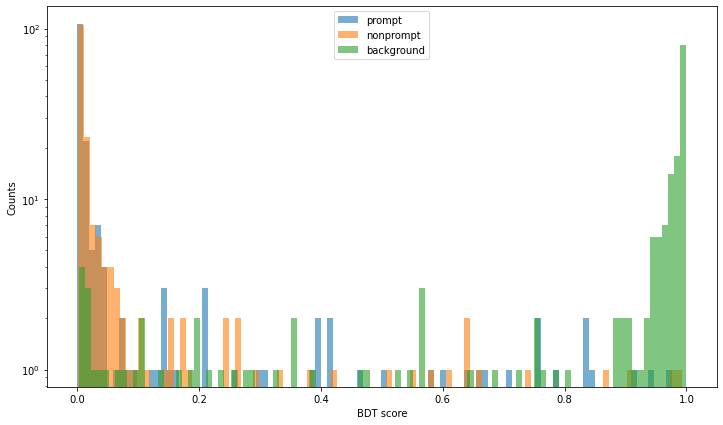

In [28]:
# Save parquet, root and pkl
parquet_path = f'{OUT_DIR}/bdt_{tag}.parquet.gzip'
df = dataH.get_data_frame()
df.to_parquet(parquet_path, index=False, compression='gzip')
# parquet_to_root(parquet_path, f'{OUT_DIR}/bdt_{tag}.root', treename='parquettree', verbose=False) # Apparently parquet_to_root is missing from the repo
model_hdl.dump_model_handler(f'{OUT_DIR}/modelBDT_{tag}.pkl')

df = dataH.get_data_frame()
y_pred = model_hdl.model.predict_proba(df[features_for_train]) # Sums to 1 for each candidate!
df['background_score'] = y_pred[:, 0] # prompt
df['prompt_score'] = y_pred[:, 1] # non-prompt
df['nonprompt_score'] = y_pred[:, 2] # background

df['prompt_score'].plot(kind='hist', bins=100, alpha=0.6, log=True, figsize=(12, 7), grid=False, label='prompt')
df['nonprompt_score'].plot(kind='hist', bins=100, alpha=0.6, log=True, figsize=(12, 7), grid=False, label='nonprompt')
df['background_score'].plot(kind='hist', bins=100, alpha=0.6, log=True, figsize=(12, 7), grid=False, label='background')
plt.xlabel('BDT score')
plt.ylabel('Counts')
plt.legend()
plt.show()

In [29]:
# Export to ONNX
features_onnx = [f.replace("f", "k", 1) if f.startswith("f") else f for f in features_for_train]
export_to_onnx(model_hdl, prefix=f"{OUT_DIR}/modelBDT_{tag}", feature_names=features_onnx, input_table=parquet_path)

print("Training and evaluation completed. Start JSON export.")

Inferred number of input features: 10
File output/MultiClass/modelBDT_pt0_100.onnx saved
Exported ONNX: output/MultiClass/modelBDT_pt0_100.onnx
  - input: shape=[1, 10]
Training and evaluation completed. Start JSON export.


## JSON Export

In [30]:
cut_vals = {"background": 0.3, "prompt": 0.5, "nonprompt": 0.4} # TODO: Update with optimized cut values

json_dict = {
    "TestCut": {
        "type": "MultiClass",
        "title": "MyBDTModel",
        "inputFeatures": features_onnx,
        "modelFiles": [],
        "cent": CENT_Type
    }
}

In [31]:
CENT_BINS = [(0, 100)]
for centmin, centmax in CENT_BINS:
    cent_key = f"AddCentCut-Cent{centmin:02d}{centmax:02d}"
    json_dict["TestCut"][cent_key] = {
        "centMin": centmin,
        "centMax": centmax
    }
    for i, (ptmin, ptmax) in enumerate(PT_BINS):
        pt_key = f"AddPtCut-pTBin{i+1}"
        model_name = f"modelBDT_cent{centmin}_{centmax}_pt{ptmin}_{ptmax}.onnx"

        json_dict["TestCut"]["modelFiles"].append(model_name)
        json_dict["TestCut"][cent_key][pt_key] = {
            "pTMin": ptmin,
            "pTMax": ptmax,
            "AddMLCut-background": {"var": "kBdtBackground", "cut": cut_vals["background"], "exclude": True},
            "AddMLCut-prompt": {"var": "kBdtPrompt", "cut": cut_vals["prompt"], "exclude": True},
            "AddMLCut-nonprompt": {"var": "kBdtNonprompt", "cut": cut_vals["nonprompt"], "exclude": False}
        }

In [32]:
json_output_path = os.path.join(OUT_DIR, "bdt_config_multiclass.json")
with open(json_output_path, "w") as f_json:
    json.dump(json_dict, f_json, indent=2)

with open(json_output_path, "r") as f_json_read:
    data = json.load(f_json_read)

hyperloop_str = json.dumps(data, separators=(',', ':'))
print("Hyperloop JSON string:\n")
print(hyperloop_str)

escaped_str = json.dumps(hyperloop_str)
print("\nLocal JSON string:\n")
print(escaped_str)

print(f"\nJSON saved to {json_output_path}")

Hyperloop JSON string:

{"TestCut":{"type":"MultiClass","title":"MyBDTModel","inputFeatures":["kITSClusterMap1","kITSChi2NCl1","kTPCNClsCR1","kTPCChi2NCl1","kTPCNSigmaEl1","kITSClusterMap2","kITSChi2NCl2","kTPCNClsCR2","kTPCChi2NCl2","kTPCNSigmaEl2"],"modelFiles":["modelBDT_cent0_100_pt0_100.onnx"],"cent":"kCentFT0C","AddCentCut-Cent00100":{"centMin":0,"centMax":100,"AddPtCut-pTBin1":{"pTMin":0,"pTMax":100,"AddMLCut-background":{"var":"kBdtBackground","cut":0.3,"exclude":true},"AddMLCut-prompt":{"var":"kBdtPrompt","cut":0.5,"exclude":true},"AddMLCut-nonprompt":{"var":"kBdtNonprompt","cut":0.4,"exclude":false}}}}}

Local JSON string:

"{\"TestCut\":{\"type\":\"MultiClass\",\"title\":\"MyBDTModel\",\"inputFeatures\":[\"kITSClusterMap1\",\"kITSChi2NCl1\",\"kTPCNClsCR1\",\"kTPCChi2NCl1\",\"kTPCNSigmaEl1\",\"kITSClusterMap2\",\"kITSChi2NCl2\",\"kTPCNClsCR2\",\"kTPCChi2NCl2\",\"kTPCNSigmaEl2\"],\"modelFiles\":[\"modelBDT_cent0_100_pt0_100.onnx\"],\"cent\":\"kCentFT0C\",\"AddCentCut-Cent00100